In [505]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# GLOBAL CONSTANTS
# =====================================

FS = 1_000_000           # 1 MHz
C = 3e8                  # Speed of light

NUM_CHANNELS = 4

# CFAR
CFAR_TRAIN = 200
CFAR_GUARD = 20
CFAR_SCALE = 4.5

# Pulse Validation
MIN_PULSE_WIDTH = 5
MAX_PULSE_WIDTH = 5000

# Frequency Estimation
FFT_PADDING = 8

# Tracking
PRI_TOL_US = 80
FREQ_TOL_HZ = 80_000
DOA_TOL_DEG = 8

print("Initialization Complete")

Initialization Complete


In [506]:
data_A = np.load("dataset_A_capture.npy")
data_B = np.load("dataset_B_capture.npy")

print("Dataset A Shape:", data_A.shape)
print("Dataset B Shape:", data_B.shape)

Dataset A Shape: (4, 300000)
Dataset B Shape: (4, 300000)


In [507]:
def summarize_dataset(data, name):

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Shape:", data.shape)

    print(
        "Real Range:",
        np.min(np.real(data)),
        np.max(np.real(data))
    )

    print(
        "Imag Range:",
        np.min(np.imag(data)),
        np.max(np.imag(data))
    )

In [508]:
summarize_dataset(data_A, "DATASET A")
summarize_dataset(data_B, "DATASET B")


DATASET A
Shape: (4, 300000)
Real Range: -3.016612455846623 3.113855694891997
Imag Range: -3.011443898805039 2.9686811580151446

DATASET B
Shape: (4, 300000)
Real Range: -2.890481150669415 3.134664334220205
Imag Range: -3.0517113522360018 2.8901086516282732


In [509]:
def prepare_signal(data):

    reference_signal = data[0]

    magnitude = np.abs(reference_signal)

    power = magnitude ** 2

    return {
        "reference_signal": reference_signal,
        "magnitude": magnitude,
        "power": power
    }

In [510]:
def plot_signal_magnitude(
    signal_dict,
    samples=50000,
    title="Signal Magnitude"
):

    magnitude = signal_dict["magnitude"]

    plt.figure(figsize=(12,4))

    plt.plot(magnitude[:samples])

    plt.title(title)

    plt.xlabel("Sample")

    plt.ylabel("Magnitude")

    plt.grid(True, alpha=0.3)

    plt.show()

    plt.close()

In [511]:
signal_A = prepare_signal(data_A)
signal_B = prepare_signal(data_B)

print(
    "Dataset A Average Power:",
    np.mean(signal_A["power"])
)

print(
    "Dataset A Max Power:",
    np.max(signal_A["power"])
)

print(
    "Dataset B Average Power:",
    np.mean(signal_B["power"])
)

print(
    "Dataset B Max Power:",
    np.max(signal_B["power"])
)

Dataset A Average Power: 0.2466651664976346
Dataset A Max Power: 9.697384040563524
Dataset B Average Power: 0.3235740717792219
Dataset B Max Power: 9.834019807880921


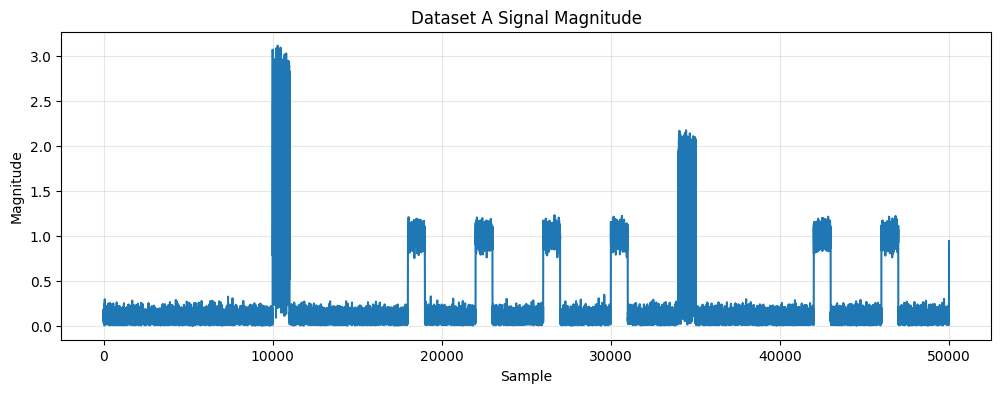

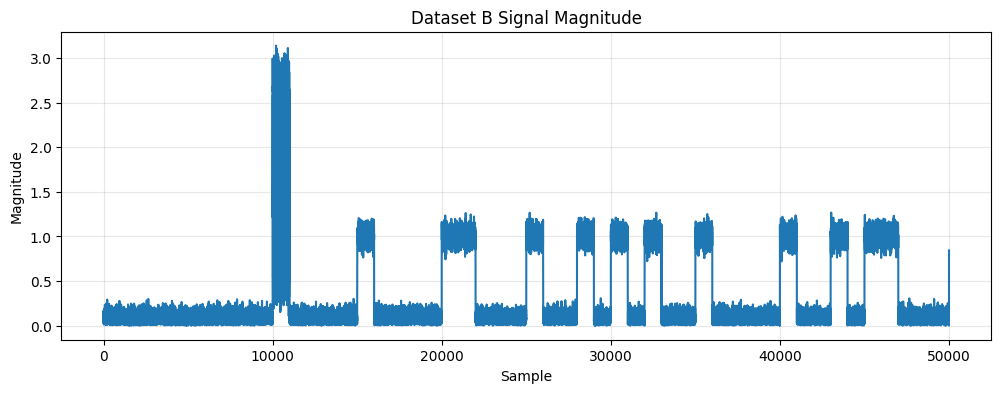

In [512]:
plot_signal_magnitude(
    signal_A,
    title="Dataset A Signal Magnitude"
)

plot_signal_magnitude(
    signal_B,
    title="Dataset B Signal Magnitude"
)

In [513]:
def cfar_detect(
    power,
    train_cells=200,
    guard_cells=20,
    scale=6.0
):

    N = len(power)

    threshold = np.zeros(N)

    start = train_cells + guard_cells
    end = N - train_cells - guard_cells

    for i in range(start, end):

        left = power[
            i-train_cells-guard_cells :
            i-guard_cells
        ]

        right = power[
            i+guard_cells+1 :
            i+guard_cells+train_cells+1
        ]

        training_cells = np.concatenate(
            (left, right)
        )

        noise_level = np.median(
            training_cells
        )

        threshold[i] = (
            scale *
            noise_level
        )

    detections = (
        power > threshold
    )

    return threshold, detections

In [514]:
threshold_A, detections_A = cfar_detect(
    signal_A["power"],
    train_cells=CFAR_TRAIN,
    guard_cells=CFAR_GUARD,
    scale=CFAR_SCALE
)

threshold_B, detections_B = cfar_detect(
    signal_B["power"],
    train_cells=CFAR_TRAIN,
    guard_cells=CFAR_GUARD,
    scale=CFAR_SCALE
)

print(
    "Dataset A Detection Ratio:",
    np.mean(detections_A)
)

print(
    "Dataset B Detection Ratio:",
    np.mean(detections_B)
)

Dataset A Detection Ratio: 0.044963333333333334
Dataset B Detection Ratio: 0.033683333333333336


In [515]:
def plot_cfar_result(
    signal_dict,
    threshold,
    samples=50000,
    title="CFAR Verification"
):

    plt.figure(figsize=(14,4))

    plt.plot(
        signal_dict["power"][:samples],
        label="Signal Power"
    )

    plt.plot(
        threshold[:samples],
        label="CFAR Threshold"
    )

    plt.title(title)

    plt.xlabel("Sample")

    plt.ylabel("Power")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.show()

    plt.close()

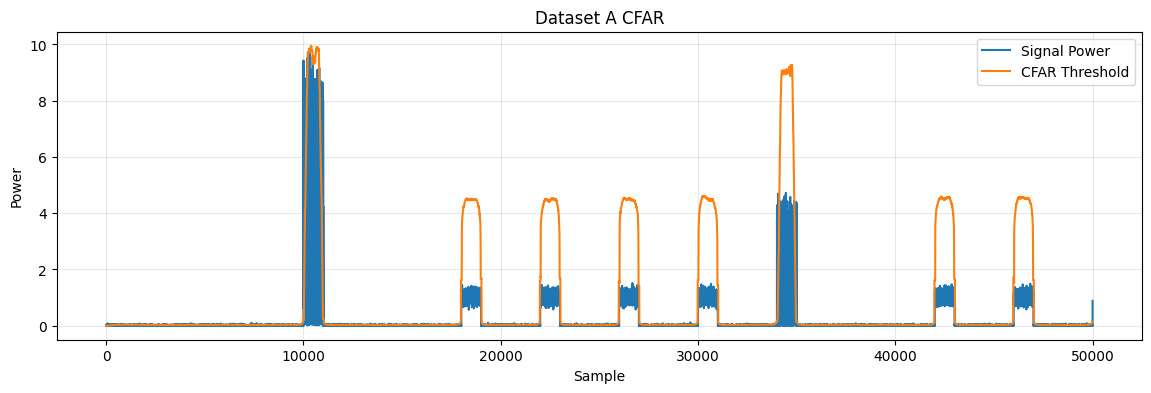

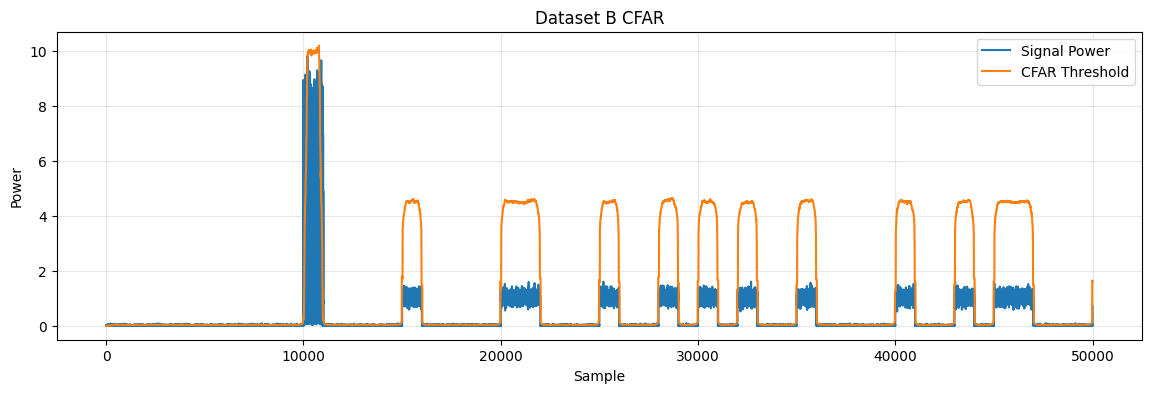

In [516]:
plot_cfar_result(
    signal_A,
    threshold_A,
    title="Dataset A CFAR"
)

plot_cfar_result(
    signal_B,
    threshold_B,
    title="Dataset B CFAR"
)

In [517]:
def cleanup_detections(
    detections,
    min_neighbors=3
):

    clean = detections.copy()

    N = len(clean)

    for i in range(2, N - 2):

        if clean[i]:

            neighborhood = np.sum(
                clean[i-2:i+3]
            )

            if neighborhood < min_neighbors:
                clean[i] = False

    return clean

In [518]:
clean_A = cleanup_detections(
    detections_A
)

clean_B = cleanup_detections(
    detections_B
)

print(
    "Dataset A Clean Ratio:",
    np.mean(clean_A)
)

print(
    "Dataset B Clean Ratio:",
    np.mean(clean_B)
)

Dataset A Clean Ratio: 0.008286666666666666
Dataset B Clean Ratio: 0.004416666666666667


In [519]:
def extract_pulses(
    clean_mask,
    power,
    fs=FS
):

    pulses = []

    inside = False

    start = 0

    N = len(clean_mask)

    for i in range(N):

        if clean_mask[i] and not inside:

            start = i
            inside = True

        elif not clean_mask[i] and inside:

            end = i

            width = end - start

            peak_idx = (
                start
                +
                np.argmax(
                    power[start:end]
                )
            )

            energy = np.sum(
                power[start:end]
            )

            pulses.append({

                "start": start,
                "end": end,
                "peak": peak_idx,
                "toa": peak_idx / fs,

                "width_samples": width,
                "width_sec": width / fs,

                "energy": energy
            })

            inside = False

    return pulses

In [520]:
pulses_A = extract_pulses(
    clean_A,
    signal_A["power"]
)

pulses_B = extract_pulses(
    clean_B,
    signal_B["power"]
)

print(
    "Dataset A Pulses:",
    len(pulses_A)
)

print(
    "Dataset B Pulses:",
    len(pulses_B)
)

Dataset A Pulses: 407
Dataset B Pulses: 173


In [521]:
def validate_pulses(
    pulses,
    min_width=5,
    max_width=5000
):

    valid = []

    for p in pulses:

        width = p["width_samples"]

        if (
            width >= min_width
            and
            width <= max_width
        ):

            valid.append(p)

    return valid

In [522]:
pulses_A = validate_pulses(
    pulses_A
)

pulses_B = validate_pulses(
    pulses_B
)

print(
    "Dataset A Valid Pulses:",
    len(pulses_A)
)

print(
    "Dataset B Valid Pulses:",
    len(pulses_B)
)

Dataset A Valid Pulses: 150
Dataset B Valid Pulses: 88


In [523]:
def pulse_statistics(
    pulses,
    dataset_name
):

    widths = np.array(
        [p["width_samples"]
         for p in pulses]
    )

    energies = np.array(
        [p["energy"]
         for p in pulses]
    )

    print("\n" + dataset_name)

    print(
        "Pulse Count:",
        len(pulses)
    )

    print(
        "Width Min:",
        np.min(widths)
    )

    print(
        "Width Mean:",
        np.mean(widths)
    )

    print(
        "Width Max:",
        np.max(widths)
    )

    print(
        "Energy Min:",
        np.min(energies)
    )

    print(
        "Energy Mean:",
        np.mean(energies)
    )

    print(
        "Energy Max:",
        np.max(energies)
    )

In [524]:
pulse_statistics(
    pulses_A,
    "DATASET A"
)

pulse_statistics(
    pulses_B,
    "DATASET B"
)


DATASET A
Pulse Count: 150
Width Min: 5
Width Mean: 9.733333333333333
Width Max: 220
Energy Min: 2.2854183580245904
Energy Mean: 19.684128926346506
Energy Max: 82.00769457639905

DATASET B
Pulse Count: 88
Width Min: 5
Width Mean: 9.636363636363637
Width Max: 220
Energy Min: 2.4263551829961645
Energy Mean: 17.40177955294413
Energy Max: 74.03597229731561


In [525]:
def estimate_pulse_frequency(
    signal,
    pulse,
    fs=FS,
    window_size=256
):

    peak = pulse["peak"]

    half = window_size // 2

    start = max(
        0,
        peak - half
    )

    end = min(
        len(signal),
        peak + half
    )

    segment = signal[start:end]

    if len(segment) < 32:
        return 0.0

    window = np.blackman(
        len(segment)
    )

    segment = segment * window

    fft_size = 8 * len(segment)

    spectrum = np.fft.fftshift(
        np.fft.fft(
            segment,
            n=fft_size
        )
    )

    mag = np.abs(spectrum)

    peak_idx = np.argmax(mag)

    if (
        1 <= peak_idx <
        len(mag)-1
    ):

        y1 = mag[peak_idx-1]
        y2 = mag[peak_idx]
        y3 = mag[peak_idx+1]

        denom = (
            y1 - 2*y2 + y3
        )

        if abs(denom) > 1e-12:

            delta = (
                0.5 *
                (y1 - y3)
                / denom
            )

        else:
            delta = 0

    else:
        delta = 0

    peak_idx = peak_idx + delta

    freq_axis = np.linspace(
        -fs/2,
        fs/2,
        fft_size,
        endpoint=False
    )

    frequency = np.interp(
        peak_idx,
        np.arange(fft_size),
        freq_axis
    )

    return frequency

In [526]:
def estimate_all_frequencies(
    signal,
    pulses
):

    frequencies = []

    for pulse in pulses:

        freq = estimate_pulse_frequency(
            signal,
            pulse
        )

        pulse["frequency"] = freq

        frequencies.append(freq)

    return frequencies

In [527]:
freqs_A = estimate_all_frequencies(
    signal_A["reference_signal"],
    pulses_A
)

freqs_B = estimate_all_frequencies(
    signal_B["reference_signal"],
    pulses_B
)

print(
    "Dataset A Frequencies Estimated:",
    len(freqs_A)
)

print(
    "Dataset B Frequencies Estimated:",
    len(freqs_B)
)

Dataset A Frequencies Estimated: 150
Dataset B Frequencies Estimated: 88


In [528]:
def frequency_statistics(
    frequencies,
    dataset_name
):

    frequencies = np.array(
        frequencies
    )

    print("\n" + dataset_name)

    print(
        "Minimum Frequency:",
        np.min(frequencies)
    )

    print(
        "Mean Frequency:",
        np.mean(frequencies)
    )

    print(
        "Maximum Frequency:",
        np.max(frequencies)
    )

    print(
        "Std Frequency:",
        np.std(frequencies)
    )

In [529]:
frequency_statistics(
    freqs_A,
    "DATASET A"
)

frequency_statistics(
    freqs_B,
    "DATASET B"
)


DATASET A
Minimum Frequency: 119802.78727964545
Mean Frequency: 300749.2353402497
Maximum Frequency: 450351.0573528342
Std Frequency: 121479.65694026274

DATASET B
Minimum Frequency: -83488.23857677073
Mean Frequency: 159395.89821630844
Maximum Frequency: 380119.57560269814
Std Frequency: 109988.57104868554


In [530]:
def plot_frequency_histogram(
    frequencies,
    title
):

    plt.figure(figsize=(10,4))

    plt.hist(
        frequencies,
        bins=40
    )

    plt.title(title)

    plt.xlabel("Frequency (Hz)")

    plt.ylabel("Count")

    plt.grid(True, alpha=0.3)

    plt.show()

    plt.close()

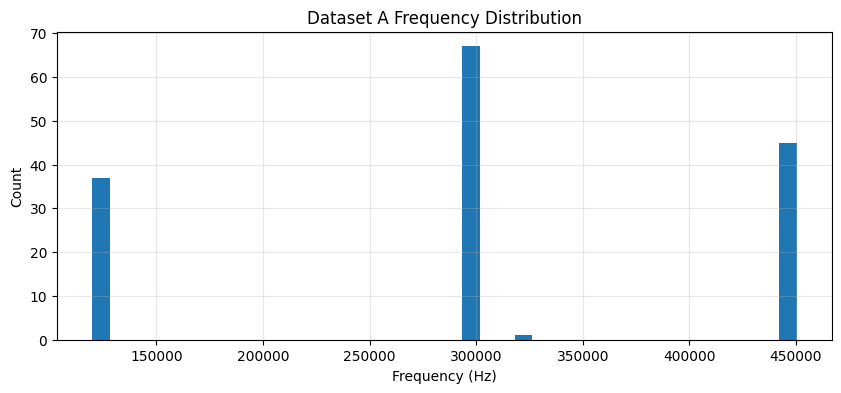

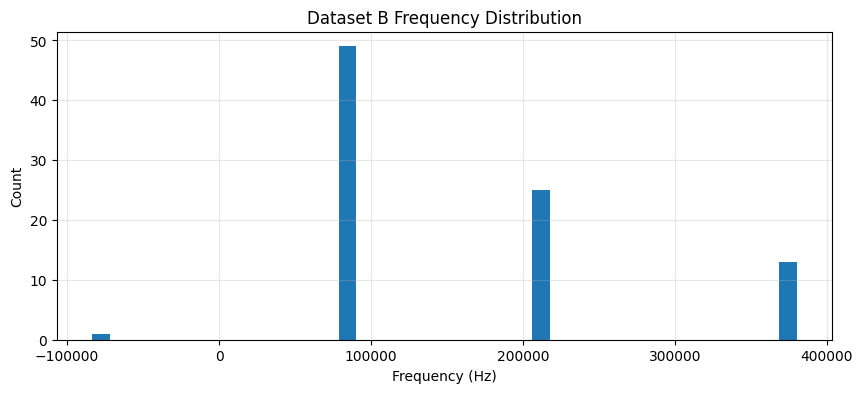

In [531]:
plot_frequency_histogram(
    freqs_A,
    "Dataset A Frequency Distribution"
)

plot_frequency_histogram(
    freqs_B,
    "Dataset B Frequency Distribution"
)

In [532]:
print("\nFirst 20 Dataset A Frequencies")

print(
    np.round(
        freqs_A[:20],
        2
    )
)

print("\nFirst 20 Dataset B Frequencies")

print(
    np.round(
        freqs_B[:20],
        2
    )
)


First 20 Dataset A Frequencies
[322124.86 299855.81 119941.78 119864.88 119939.7  119964.17 119991.24
 299997.92 300011.62 300019.4  300028.84 450224.23 450167.22 450118.91
 450083.8  450060.89 450040.31 450024.87 450015.03 299983.66]

First 20 Dataset B Frequencies
[-83488.24 380059.84  79906.05 210017.7  210024.31 210031.53 210038.17
 210044.97 210052.13 210058.02 210062.16  79850.18  79935.11  79981.09
  80006.51  80020.98  80046.56  80069.93  80102.04  80146.26]


In [533]:
widths_A = np.array(
    [p["width_samples"]
     for p in pulses_A]
)

print(
    "A Width Percentiles:"
)

print(
    np.percentile(
        widths_A,
        [10,25,50,75,90,95]
    )
)

widths_B = np.array(
    [p["width_samples"]
     for p in pulses_B]
)

print(
    "B Width Percentiles:"
)

print(
    np.percentile(
        widths_B,
        [10,25,50,75,90,95]
    )
)

A Width Percentiles:
[ 5.  5.  6. 10. 11. 26.]
B Width Percentiles:
[ 5.   5.   6.   7.5  9.  14. ]


In [534]:
def print_rf_groups(freqs):

    freqs = np.sort(np.array(freqs))

    print("\nUnique RF Regions")

    gaps = np.diff(freqs)

    split_points = np.where(
        gaps > 50000
    )[0]

    start = 0

    for split in split_points:

        group = freqs[start:split+1]

        print(
            f"Group: "
            f"{np.mean(group):.0f} Hz "
            f"({len(group)} pulses)"
        )

        start = split + 1

    group = freqs[start:]

    print(
        f"Group: "
        f"{np.mean(group):.0f} Hz "
        f"({len(group)} pulses)"
    )

In [535]:
print("DATASET A")
print_rf_groups(freqs_A)

print("\nDATASET B")
print_rf_groups(freqs_B)

DATASET A

Unique RF Regions
Group: 119944 Hz (37 pulses)
Group: 300303 Hz (68 pulses)
Group: 450085 Hz (45 pulses)

DATASET B

Unique RF Regions
Group: -83488 Hz (1 pulses)
Group: 79996 Hz (49 pulses)
Group: 210029 Hz (25 pulses)
Group: 379986 Hz (13 pulses)


In [536]:
def compute_spatial_signature(
    data,
    pulse
):

    start = pulse["start"]
    end = pulse["end"]

    snapshot = data[:, start:end]

    if snapshot.shape[1] < 4:

        return [0.0, 0.0, 0.0]

    phases = []

    for k in range(1, 4):

        r = np.mean(
            snapshot[k] *
            np.conj(snapshot[k-1])
        )

        phases.append(
            np.angle(r)
        )

    return phases

In [537]:
def add_spatial_features(
    data,
    pulses
):

    for pulse in pulses:

        sig = compute_spatial_signature(
            data,
            pulse
        )

        pulse["phase01"] = sig[0]
        pulse["phase12"] = sig[1]
        pulse["phase23"] = sig[2]

In [538]:
add_spatial_features(
    data_A,
    pulses_A
)

add_spatial_features(
    data_B,
    pulses_B
)

print("Spatial Features Added")

Spatial Features Added


In [539]:
def build_pdws(
    pulses
):

    pdws = []

    for pulse in pulses:

        pdw = {

            "toa":
            pulse["toa"],

            "frequency":
            pulse["frequency"],

            "width":
            pulse["width_sec"],

            "energy":
            pulse["energy"],

            "phase01": pulse["phase01"],
            "phase12": pulse["phase12"],
            "phase23": pulse["phase23"]

        }

        pdws.append(pdw)

    return pdws

In [540]:
pdws_A = build_pdws(
    pulses_A
)

pdws_B = build_pdws(
    pulses_B
)

print(
    "Dataset A PDWs:",
    len(pdws_A)
)

print(
    "Dataset B PDWs:",
    len(pdws_B)
)

Dataset A PDWs: 150
Dataset B PDWs: 88


In [541]:
def sort_pdws(pdws):

    return sorted(
        pdws,
        key=lambda x: x["toa"]
    )

In [542]:
pdws_A = sort_pdws(
    pdws_A
)

pdws_B = sort_pdws(
    pdws_B
)

In [543]:
def initial_rf_groups(
    pdws,
    gap_hz=50000
):

    pdws = sorted(
        pdws,
        key=lambda p:
        p["frequency"]
    )

    groups = []

    current = [pdws[0]]

    for i in range(
        1,
        len(pdws)
    ):

        diff = abs(
            pdws[i]["frequency"]
            -
            pdws[i-1]["frequency"]
        )

        if diff < gap_hz:

            current.append(
                pdws[i]
            )

        else:

            groups.append(
                current
            )

            current = [pdws[i]]

    groups.append(
        current
    )

    return groups

In [544]:
rf_groups_A = initial_rf_groups(
    pdws_A
)

rf_groups_B = initial_rf_groups(
    pdws_B
)

print(
    "Dataset A RF Groups:",
    len(rf_groups_A)
)

print(
    "Dataset B RF Groups:",
    len(rf_groups_B)
)

Dataset A RF Groups: 3
Dataset B RF Groups: 4


In [545]:
def merge_close_pulses(
    pulses,
    max_gap_samples=10
):
    """
    Merge pulse fragments that are
    separated by only a few samples.
    """

    if len(pulses) == 0:
        return []

    merged = []

    current = pulses[0].copy()

    for p in pulses[1:]:

        gap = (
            p["start"]
            -
            current["end"]
        )

        if gap <= max_gap_samples:

            current["end"] = p["end"]

            current["energy"] += p["energy"]

            if p["energy"] > current["energy"]:
                current["peak"] = p["peak"]

        else:

            merged.append(current)

            current = p.copy()

    merged.append(current)

    return merged

In [546]:
pulses_A = merge_close_pulses(
    pulses_A,
    max_gap_samples=10
)

pulses_B = merge_close_pulses(
    pulses_B,
    max_gap_samples=10
)

print(len(pulses_A))
print(len(pulses_B))

37
16


In [547]:
# =====================================
# REBUILD FEATURES AFTER MERGING
# =====================================

freqs_A = estimate_all_frequencies(
    signal_A["reference_signal"],
    pulses_A
)

freqs_B = estimate_all_frequencies(
    signal_B["reference_signal"],
    pulses_B
)

add_spatial_features(
    data_A,
    pulses_A
)

add_spatial_features(
    data_B,
    pulses_B
)

pdws_A = build_pdws(
    pulses_A
)

pdws_B = build_pdws(
    pulses_B
)

pdws_A = sort_pdws(
    pdws_A
)

pdws_B = sort_pdws(
    pdws_B
)

rf_groups_A = initial_rf_groups(
    pdws_A
)

rf_groups_B = initial_rf_groups(
    pdws_B
)

In [548]:
def create_track(seed_pulse):

    return {

        "pulses": [seed_pulse],

        "rf_mean":
        seed_pulse["frequency"],

        "pw_mean":
        seed_pulse["width"],

        "energy_mean":
        seed_pulse["energy"],

        "phase01_mean":
        seed_pulse["phase01"],

        "phase12_mean":
        seed_pulse["phase12"],

        "phase23_mean":
        seed_pulse["phase23"]

    }

In [549]:
def pulse_matches_track(
    pulse,
    track,
    rf_tol=30000,
    pw_tol=50e-6
):

    rf_error = abs(
        pulse["frequency"]
        -
        track["rf_mean"]
    )

    pw_error = abs(
        pulse["width"]
        -
        track["pw_mean"]
    )

    return (
        rf_error < rf_tol
        and
        pw_error < pw_tol
    )

In [550]:
def update_track(
    track,
    pulse
):

    track["pulses"].append(
        pulse
    )

    freqs = [
        p["frequency"]
        for p in track["pulses"]
    ]

    widths = [
        p["width"]
        for p in track["pulses"]
    ]

    energies = [
        p["energy"]
        for p in track["pulses"]
    ]

    ph1 = [
        p["phase01"]
        for p in track["pulses"]
    ]

    ph2 = [
        p["phase12"]
        for p in track["pulses"]
    ]

    ph3 = [
        p["phase23"]
        for p in track["pulses"]
    ]

    track["rf_mean"] = np.mean(
        freqs
    )

    track["pw_mean"] = np.mean(
        widths
    )

    track["energy_mean"] = np.mean(
        energies
    )

    track["phase01_mean"] = np.mean(
        ph1
    )

    track["phase12_mean"] = np.mean(
        ph2
    )

    track["phase23_mean"] = np.mean(
        ph3
    )

In [551]:
def estimate_track_doa(track):

    mean_phase = np.mean([

        track["phase01_mean"],
        track["phase12_mean"],
        track["phase23_mean"]

    ])

    arg = np.clip(
        mean_phase / np.pi,
        -1,
        1
    )

    return np.degrees(
        np.arcsin(arg)
    )

In [552]:
def build_tracks(
    pdws
):

    tracks = []

    for pulse in pdws:

        assigned = False

        for track in tracks:

            if pulse_matches_track(
                pulse,
                track
            ):

                update_track(
                    track,
                    pulse
                )

                assigned = True

                break

        if not assigned:

            tracks.append(
                create_track(
                    pulse
                )
            )

    return tracks

In [553]:
tracks_A = build_tracks(
    pdws_A
)

tracks_B = build_tracks(
    pdws_B
)

print(
    "Dataset A Tracks:",
    len(tracks_A)
)

print(
    "Dataset B Tracks:",
    len(tracks_B)
)

Dataset A Tracks: 4
Dataset B Tracks: 4


In [554]:
def print_track_summary(
    tracks,
    name
):

    print("\n" + name)

    for i, track in enumerate(
        tracks
    ):

        print(
            f"\nTrack {i+1}"
        )

        print(
            "Pulses:",
            len(
                track["pulses"]
            )
        )

        print(
            "RF:",
            f"{track['rf_mean']:.0f} Hz"
        )

        print(
            "PW:",
            f"{track['pw_mean']*1e6:.2f} us"
        )

In [555]:
print_track_summary(
    tracks_A,
    "DATASET A"
)

print_track_summary(
    tracks_B,
    "DATASET B"
)


DATASET A

Track 1
Pulses: 1
RF: 322125 Hz
PW: 220.00 us

Track 2
Pulses: 14
RF: 299982 Hz
PW: 8.43 us

Track 3
Pulses: 12
RF: 119937 Hz
PW: 13.33 us

Track 4
Pulses: 10
RF: 450063 Hz
PW: 17.50 us

DATASET B

Track 1
Pulses: 1
RF: -83488 Hz
PW: 220.00 us

Track 2
Pulses: 3
RF: 380025 Hz
PW: 11.33 us

Track 3
Pulses: 8
RF: 79986 Hz
PW: 8.75 us

Track 4
Pulses: 4
RF: 210037 Hz
PW: 5.00 us


In [556]:
def remove_small_tracks(
    tracks,
    min_pulses=2
):

    return [

        t

        for t in tracks

        if len(
            t["pulses"]
        ) >= min_pulses

    ]

In [557]:
tracks_A = remove_small_tracks(
    tracks_A
)

tracks_B = remove_small_tracks(
    tracks_B
)

print(
    "Dataset A Valid Tracks:",
    len(tracks_A)
)

print(
    "Dataset B Valid Tracks:",
    len(tracks_B)
)

Dataset A Valid Tracks: 3
Dataset B Valid Tracks: 3


In [558]:
def estimate_track_pri(
    track
):

    toas = np.array([

        p["toa"]

        for p in track["pulses"]

    ])

    toas = np.sort(
        toas
    )

    if len(toas) < 3:

        return None

    intervals = np.diff(
        toas
    )

    pri = np.median(
        intervals
    )

    return pri

In [559]:
def print_pris(
    tracks,
    name
):

    print("\n" + name)

    for i, track in enumerate(
        tracks
    ):

        pri = estimate_track_pri(
            track
        )

        if pri is None:
            continue

        print(
            f"Track {i+1}"
        )

        print(
            "RF:",
            f"{track['rf_mean']:.0f} Hz"
        )

        print(
            "PRI:",
            f"{pri*1000:.3f} ms"
        )

        print()

In [560]:
print_pris(
    tracks_A,
    "DATASET A"
)

print_pris(
    tracks_B,
    "DATASET B"
)


DATASET A
Track 1
RF: 299982 Hz
PRI: 23.994 ms

Track 2
RF: 119937 Hz
PRI: 23.995 ms

Track 3
RF: 450063 Hz
PRI: 19.019 ms


DATASET B
Track 1
RF: 380025 Hz
PRI: 98.992 ms

Track 2
RF: 79986 Hz
PRI: 19.971 ms

Track 3
RF: 210037 Hz
PRI: 54.069 ms



In [563]:
def build_emitter_table(tracks):

    emitters = []

    for i, track in enumerate(tracks):

        pri = estimate_track_pri(track)

        doa = estimate_track_doa(track)

        emitter = {

            "Emitter_ID": i + 1,

            "Carrier_Frequency_Hz":
            round(track["rf_mean"], 2),

            "PRI_ms":
            round(pri * 1000, 3),

            "DoA_deg":
            round(doa, 2),

            "Pulse_Width_us":
            round(
                track["pw_mean"] * 1e6,
                2
            ),

            "Pulse_Count":
            len(track["pulses"])

        }

        emitters.append(emitter)

    return emitters

In [564]:
final_emitters_A = build_emitter_table(
    tracks_A
)

final_emitters_B = build_emitter_table(
    tracks_B
)

print("DATASET A")
for emitter in final_emitters_A:
    print(emitter)

print("\nDATASET B")
for emitter in final_emitters_B:
    print(emitter)

DATASET A
{'Emitter_ID': 1, 'Carrier_Frequency_Hz': np.float64(299982.26), 'PRI_ms': np.float64(23.994), 'DoA_deg': np.float64(-41.12), 'Pulse_Width_us': np.float64(8.43), 'Pulse_Count': 14}
{'Emitter_ID': 2, 'Carrier_Frequency_Hz': np.float64(119937.07), 'PRI_ms': np.float64(23.995), 'DoA_deg': np.float64(-44.36), 'Pulse_Width_us': np.float64(13.33), 'Pulse_Count': 12}
{'Emitter_ID': 3, 'Carrier_Frequency_Hz': np.float64(450062.73), 'PRI_ms': np.float64(19.019), 'DoA_deg': np.float64(-1.65), 'Pulse_Width_us': np.float64(17.5), 'Pulse_Count': 10}

DATASET B
{'Emitter_ID': 1, 'Carrier_Frequency_Hz': np.float64(380024.72), 'PRI_ms': np.float64(98.992), 'DoA_deg': np.float64(-43.33), 'Pulse_Width_us': np.float64(11.33), 'Pulse_Count': 3}
{'Emitter_ID': 2, 'Carrier_Frequency_Hz': np.float64(79986.25), 'PRI_ms': np.float64(19.971), 'DoA_deg': np.float64(-47.8), 'Pulse_Width_us': np.float64(8.75), 'Pulse_Count': 8}
{'Emitter_ID': 3, 'Carrier_Frequency_Hz': np.float64(210037.31), 'PRI_ms': np

In [565]:
import pandas as pd

df_A = pd.DataFrame(
    final_emitters_A
)

df_B = pd.DataFrame(
    final_emitters_B
)

print("\nDATASET A")
display(df_A)

print("\nDATASET B")
display(df_B)


DATASET A


,Emitter_ID,Carrier_Frequency_Hz,PRI_ms,DoA_deg,Pulse_Width_us,Pulse_Count
0,1,299982.26,23.994,-41.12,8.43,14
1,2,119937.07,23.995,-44.36,13.33,12
2,3,450062.73,19.019,-1.65,17.50,10



DATASET B


,Emitter_ID,Carrier_Frequency_Hz,PRI_ms,DoA_deg,Pulse_Width_us,Pulse_Count
0,1,380024.72,98.992,-43.33,11.33,3
1,2,79986.25,19.971,-47.80,8.75,8
2,3,210037.31,54.069,-36.78,5.00,4
